In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ScanpathsAnalyzer,
)


config = CustomConfig('./configs/config.yaml')
loader = DataLoader(config, root='./')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-37.158631,-175.536547,643


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_121156,-37.158631,-175.536547,643


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_121156,0,-109.802372,-239.826087,253
1,20260915_121156,1,120.515337,36.963190,163
2,20260915_121156,2,-69.414097,-256.471366,227


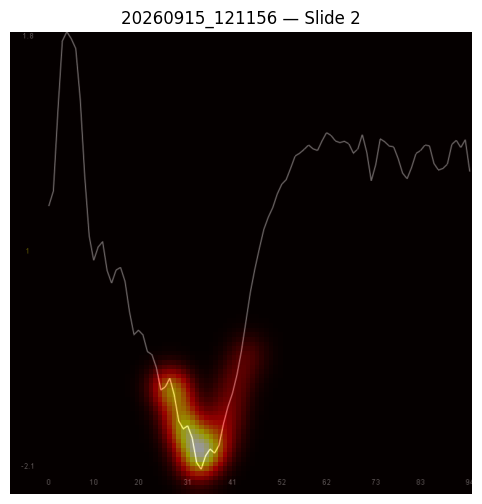

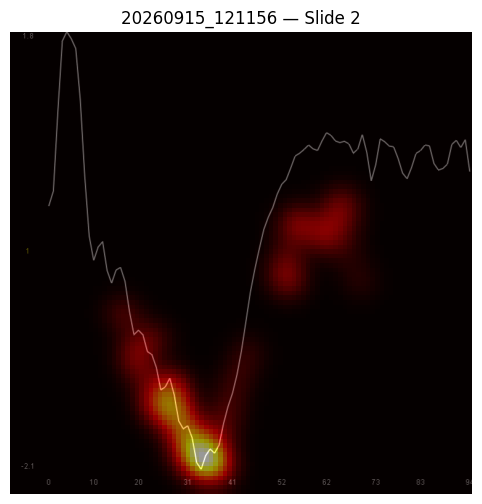

In [9]:
# Assuming you already have the data
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-37.158631,-175.536547,643


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_121156,-37.158631,-175.536547,643


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260915_121156,0,-109.802372,-239.826087,253
1,20260915_121156,1,120.515337,36.963190,163
2,20260915_121156,2,-69.414097,-256.471366,227


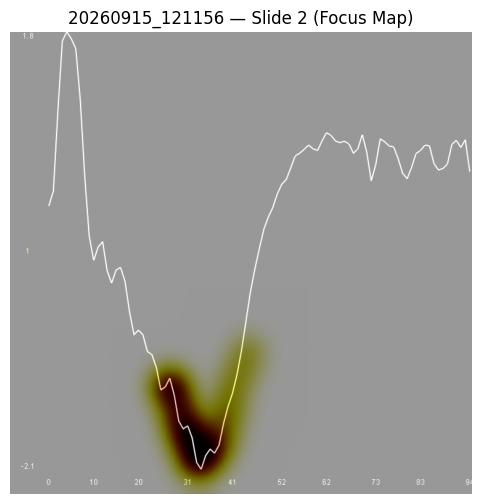

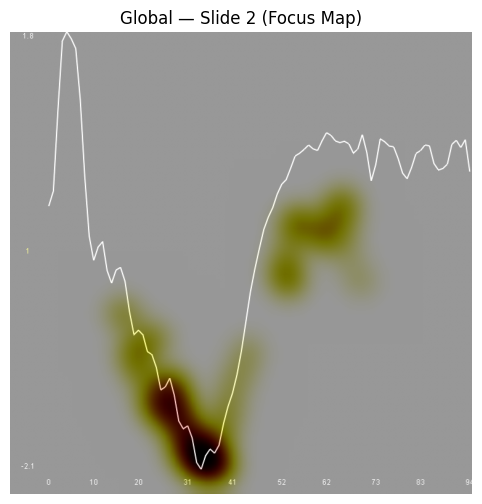

In [10]:
# --- Prepare background data ---
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260915_121156,0,13.121079,13.121079,0.031945,-190.0,-82.0,-189.0,-84.0,2.236068,69.998309,69.998309,2343.826469
1,20260915_121156,0,13.282112,13.361189,0.110760,-183.0,-93.0,-135.0,-121.0,55.569776,1291.993774,612.049503,26016.432097
2,20260915_121156,0,13.442313,13.473327,0.063661,-138.0,-122.0,-145.0,-125.0,7.615773,187.690923,125.567085,3989.693201
3,20260915_121156,0,13.567602,13.633139,0.080196,-152.0,-128.0,-160.0,-132.0,8.944272,152.533714,107.171196,3604.507593
4,20260915_121156,0,13.792866,13.841139,0.063235,-169.0,-139.0,-173.0,-142.0,5.000000,149.437819,105.134931,1949.248928


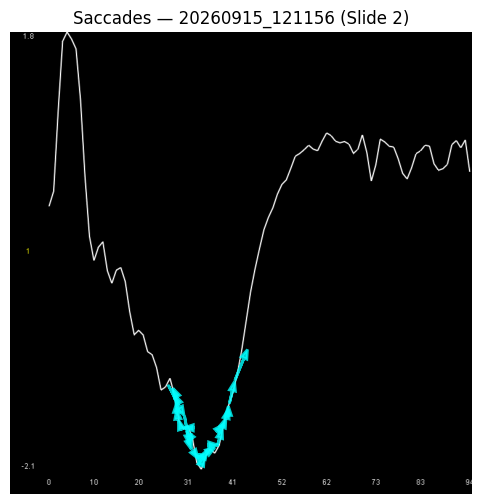

In [11]:
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[-1]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,12.932720,13.297688,0.364969,-187.631579,-86.789474,77.0,20260915_121156,0
1,13.313847,13.841139,0.527291,-153.666667,-129.703704,61.0,20260915_121156,0
2,13.858001,14.398589,0.540588,-166.500000,-165.178571,75.0,20260915_121156,0
3,14.414972,15.097655,0.682683,-139.285714,-225.457143,64.0,20260915_121156,0
4,15.113954,15.817787,0.703833,-113.500000,-243.555556,68.0,20260915_121156,0


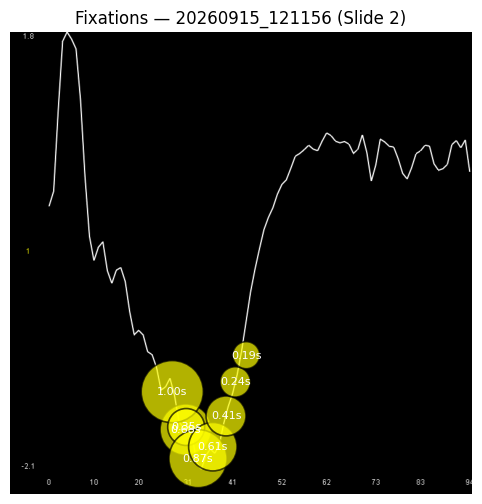

In [12]:
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[-1]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

In [13]:
background_data.head()

,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,objects_bboxes,voice_file,voice_start_timestamp,...,system_time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size
0,20260915_121156,0,output\20260915_121156\0.50205548.png,[ 0.54216265 0.72238348 1.4288852 2.136515...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,12.932720,-197.0,-80.0,None,None,5,0,-197.0,-80.0,2.5
1,20260915_121156,0,output\20260915_121156\0.50205548.png,[ 0.54216265 0.72238348 1.4288852 2.136515...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,12.946948,-197.0,-80.0,None,None,5,0,-197.0,-80.0,2.5
2,20260915_121156,0,output\20260915_121156\0.50205548.png,[ 0.54216265 0.72238348 1.4288852 2.136515...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,12.977045,-197.0,-80.0,None,None,5,0,-197.0,-80.0,2.5
3,20260915_121156,0,output\20260915_121156\0.50205548.png,[ 0.54216265 0.72238348 1.4288852 2.136515...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,12.994437,-196.0,-80.0,None,None,5,0,-196.0,-80.0,2.5
4,20260915_121156,0,output\20260915_121156\0.50205548.png,[ 0.54216265 0.72238348 1.4288852 2.136515...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,13.011395,-194.0,-80.0,None,None,5,0,-194.0,-80.0,2.5


▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,objects_bboxes,voice_file,voice_start_timestamp,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260915_121156,2,output\20260915_121156\0.31664616.png,[ 0.24319908 0.37047144 1.0637381 1.678187...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,-80.0,-280.0,None,None,5,0,-80.0,-280.0,2.5,0
1,20260915_121156,2,output\20260915_121156\0.31664616.png,[ 0.24319908 0.37047144 1.0637381 1.678187...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,-80.0,-280.0,None,None,5,0,-80.0,-280.0,2.5,0
2,20260915_121156,2,output\20260915_121156\0.31664616.png,[ 0.24319908 0.37047144 1.0637381 1.678187...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,-80.0,-280.0,None,None,5,0,-80.0,-280.0,2.5,0
3,20260915_121156,2,output\20260915_121156\0.31664616.png,[ 0.24319908 0.37047144 1.0637381 1.678187...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,-81.0,-280.0,None,None,5,0,-81.0,-280.0,2.5,0
4,20260915_121156,2,output\20260915_121156\0.31664616.png,[ 0.24319908 0.37047144 1.0637381 1.678187...,abnormal,normal,None,"{'timeseries_bboxes': [{'channel_idx': 0, 'cha...",NaN,NaN,...,-81.0,-280.0,None,None,5,0,-81.0,-280.0,2.5,0


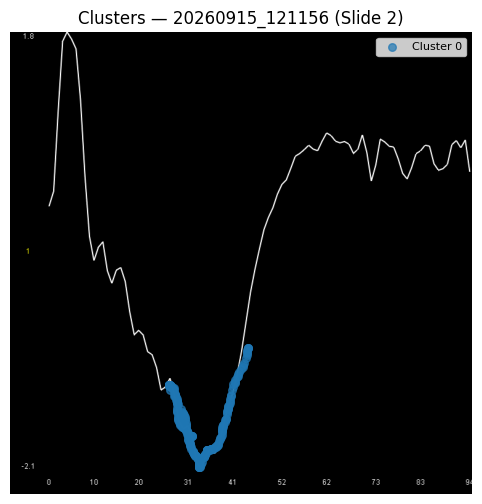

In [14]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

#background_data= loader.get_all_data(flatten=True)
background_data= loader.get_slide_data(loader.get_subjects()[-1],-1,flatten=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,6.698610,11830.5,253,20260915_121156,0
1,6.667387,12843.5,163,20260915_121156,1
2,6.902201,12192.5,227,20260915_121156,2


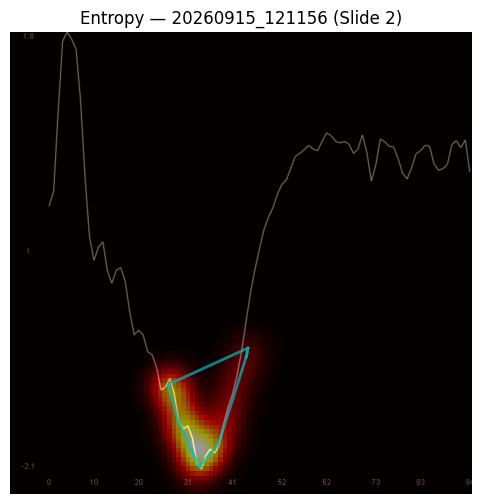

In [15]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = loader.get_all_data(flatten=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[-1]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)
